In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

## a


In [23]:
file = pd.read_csv("./YearPredictionMSD.txt", header=None, delimiter=',').dropna()

# b

In [24]:
train_df = file.iloc[:463715]
test_df  = file.iloc[463715:]

# c

In [25]:
years = train_df.iloc[:, 0].tolist()

min_year = min(years)
max_year = max(years)

In [28]:
buckets = abs(max_year - min_year)
print(buckets)

89


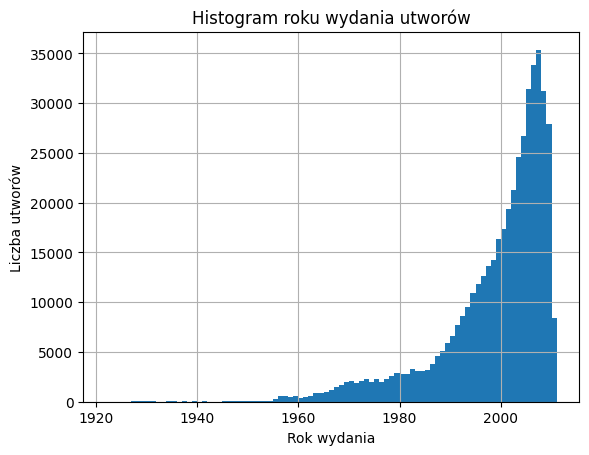

In [29]:
train_df[0].hist(bins=buckets)
plt.title('Histogram roku wydania utworów')
plt.xlabel('Rok wydania')
plt.ylabel('Liczba utworów')
plt.show()

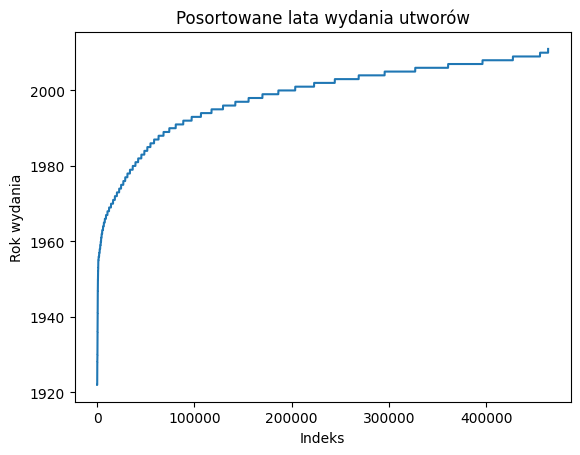

In [5]:
plt.plot(train_df[0].sort_values().values)
plt.title('Posortowane lata wydania utworów')
plt.xlabel('Indeks')
plt.ylabel('Rok wydania')
plt.show()

# d

In [6]:
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test = test_df.iloc[:, 0].values
X_test = test_df.iloc[:, 1:].values

A_train = np.c_[np.ones(X_train.shape[0]), X_train]
A_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [7]:
f_min = X_train.min(axis=0)
f_max = X_train.max(axis=0)

denominator_f = np.where((f_max - f_min) == 0, 1, (f_max - f_min))

In [8]:
X_train_scaled = (X_train - f_min) / denominator_f
X_test_scaled = (X_test - f_min) / denominator_f

A_train_scaled = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
A_test_scaled = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [9]:

y_min = y_train.min()
y_max = y_train.max()

denominator_y = 1 if (y_max - y_min) == 0 else (y_max - y_min)

y_train_scaled = (y_train - y_min) / denominator_y
y_test_scaled = (y_test - y_min) / denominator_y

# e

In [10]:
def fit_ols(A, y): # ordinary least squares
    M = A.T @ A
    v = A.T @ y
    w = np.linalg.solve(M, v)
    return w

In [11]:

w_unscaled = fit_ols(A_train, y_train)
w_scaled = fit_ols(A_train_scaled, y_train_scaled)

In [12]:
print(f"Wymiary wektora wag (surowe): {w_unscaled.shape}")
print(f"Wymiary wektora wag (znormalizowane): {w_scaled.shape}")

Wymiary wektora wag (surowe): (91,)
Wymiary wektora wag (znormalizowane): (91,)


# f

In [13]:
def fit_svd(A,y):

    weights,_,_,_ = scipy.linalg.lstsq(A,y)
    return weights

In [14]:
def fit_svd_with_lambda(A,y,lamb):
    I = np.identity(A.shape[1])
    I[0,0] = 0
    M = A.T @ A + lamb*I
    N = A.T @ y

    weights = scipy.linalg.solve(M,N)
    return weights

In [15]:
w_unscaled_svd = fit_svd(A_train, y_train)

lamb = 0.01
w_regularized_svd = fit_svd_with_lambda(A_train, y_train,lamb)

In [16]:
print(f"Wymiary wektora wag (svd): {w_unscaled_svd.shape}")
print(f"Wymiary wektora wag (zregularyzowane równanie normalne): {w_regularized_svd.shape}")


Wymiary wektora wag (svd): (91,)
Wymiary wektora wag (zregularyzowane równanie normalne): (91,)


# g

In [17]:
A_cond_number = np.linalg.cond(A_train.T @ A_train)
A_cond_number_scaled = np.linalg.cond(A_train_scaled.T @ A_train_scaled)

In [18]:
print(f"Współczynnik uwarunkowania macierzy nieznormalizowanej: {A_cond_number}")
print(f"Współczynnik uwarunkowania macierzy znormalizowanej: {A_cond_number_scaled}")

Współczynnik uwarunkowania macierzy nieznormalizowanej: 3873665565.792903
Współczynnik uwarunkowania macierzy znormalizowanej: 2146480.9788554627


In [19]:
print(f"Utrata cyfr znaczących dla macierzy nieznormalizowanej: {np.round(np.log10(A_cond_number))}")
print(f"Utrata cyfr znaczących dla macierzy znormalizowanej: {np.round(np.log10(A_cond_number_scaled))}")

Utrata cyfr znaczących dla macierzy nieznormalizowanej: 10.0
Utrata cyfr znaczących dla macierzy znormalizowanej: 6.0


# h

In [20]:
weights_check_raw = A_test @ w_unscaled
weights_check_scaled = A_test_scaled @ w_scaled

weights_check_scaled_adjusted = weights_check_scaled*(y_max-y_min)+ y_min
error1 = np.average(abs(weights_check_scaled_adjusted-y_test))
error2 = np.average(abs(weights_check_raw-y_test))


In [21]:
print(error1)
print(error2)

6.800496463186168
6.80049646318614


# i

In [22]:
A_train_list = [A_train[i*100000:(i+1)*100000] for i in range(5)]
y_train_list = [y_train[i*100000:(i+1)*100000] for i in range(5)]
w = np.zeros(A_test.shape[1])
H = np.zeros((A_test.shape[1],A_test.shape[1]))
for i in range(len(A_train_list)):
    A_i = A_train_list[i]
    y_i = y_train_list[i]
    H_i = H+A_i.T @ A_i
    d_i = np.linalg.solve(H_i,A_i.T @ (y_i-A_i@w))
    w_i = w+d_i

    w,H = w_i,H_i
    error = np.average(abs( A_test @ w - y_test ))
    print(f"iteration: {i+1}, error: {error}")
#print(w)

iteration: 1, error: 6.811239009023011
iteration: 2, error: 6.7727039050752005
iteration: 3, error: 6.764695916584969
iteration: 4, error: 6.766915230164339
iteration: 5, error: 6.76638274090286
